# 03 — Price Prediction Model

**Task:** Regression — predict `log1p(price)` per listing-night
**Why log:** Heavy right-skew in price; log target stabilizes residuals and
makes RMSE behave like a relative error.

## Pipeline
1. Load engineered features
2. Train/validation split (random, stratified by room_type)
3. Models compared:
   - Linear baseline (`Ridge` on encoded features)
   - `RandomForest`
   - `XGBoost` (tuned with Optuna)
4. **Cross-validation** with 5-fold KFold
5. **SHAP** explainability on the winning model


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

from src.data_loader import load_processed

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore', category=FutureWarning)


In [2]:
df = load_processed('listings_features')
print(f'Shape: {df.shape}')

# Target
df['log_price'] = np.log1p(df['price'])
y = df['log_price']

# Drop columns not used as features
drop = ['id','price','log_price','neighbourhood_norm','latitude','longitude']
X = df.drop(columns=[c for c in drop if c in df.columns])
print(f'X: {X.shape}, y: {y.shape}')

Shape: (5244, 54)
X: (5244, 49), y: (5244,)


## 1. Train/test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=X['room_type']
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (4195, 49), Test: (1049, 49)


## 2. Preprocessing pipeline

In [4]:
# Identify column types
cat_cols = X.select_dtypes(include=['object', 'str', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number','bool']).columns.tolist()
# 'boolean' dtype (pandas nullable) won't always be picked up — coerce
for c in X.columns:
    if X[c].dtype.name == 'boolean':
        if c not in num_cols: num_cols.append(c)

print(f'Categorical ({len(cat_cols)}): {cat_cols}')
print(f'Numeric ({len(num_cols)}): first 10: {num_cols[:10]}')

Categorical (3): ['room_type', 'property_type', 'neighbourhood_cleansed']
Numeric (46): first 10: ['accommodates', 'bedrooms', 'beds', 'bathrooms', 'minimum_nights', 'availability_30', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating']


C:\Users\slaye\AppData\Local\Temp\ipykernel_23476\3419228359.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()


In [5]:
# Convert nullable boolean -> int for ML libs
for c in num_cols:
    if X_train[c].dtype.name == 'boolean':
        X_train[c] = X_train[c].astype('Int64').astype('float64')
        X_test[c]  = X_test[c].astype('Int64').astype('float64')

preprocess = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('sc',  StandardScaler()),
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('oh',  OneHotEncoder(handle_unknown='ignore', min_frequency=20)),
    ]), cat_cols),
])

## 3. Evaluation helpers

In [6]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    # Metrics on log scale
    metrics = {
        'model': name,
        'rmse_log_train': np.sqrt(mean_squared_error(y_tr, pred_tr)),
        'rmse_log_test':  np.sqrt(mean_squared_error(y_te, pred_te)),
        'mae_log_test':   mean_absolute_error(y_te, pred_te),
        'r2_test':        r2_score(y_te, pred_te),
    }
    # Metrics on € scale (back-transform)
    price_pred = np.expm1(pred_te)
    price_true = np.expm1(y_te)
    metrics['rmse_eur'] = np.sqrt(mean_squared_error(price_true, price_pred))
    metrics['mae_eur']  = mean_absolute_error(price_true, price_pred)
    return metrics, model

results = []

## 4. Model 1 — Ridge baseline

In [7]:
ridge_pipe = Pipeline([
    ('pre', preprocess),
    ('reg', Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
m, ridge_fitted = evaluate(ridge_pipe, X_train, y_train, X_test, y_test, 'Ridge')
results.append(m); m

{'model': 'Ridge',
 'rmse_log_train': np.float64(0.393938980877346),
 'rmse_log_test': np.float64(0.4149832763559433),
 'mae_log_test': 0.28136274649055015,
 'r2_test': 0.6551461334699573,
 'rmse_eur': np.float64(178.46789906838535),
 'mae_eur': 64.7022839485152}

## 5. Model 2 — Random Forest

In [8]:
rf_pipe = Pipeline([
    ('pre', preprocess),
    ('reg', RandomForestRegressor(
        n_estimators=400, max_depth=18, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE,
    )),
])
m, rf_fitted = evaluate(rf_pipe, X_train, y_train, X_test, y_test, 'RandomForest')
results.append(m); m

{'model': 'RandomForest',
 'rmse_log_train': np.float64(0.19928666377254173),
 'rmse_log_test': np.float64(0.3708476844819223),
 'mae_log_test': 0.24279560328222746,
 'r2_test': 0.7245992918174171,
 'rmse_eur': np.float64(158.12427179706538),
 'mae_eur': 57.669704729275786}

## 6. Model 3 — XGBoost

In [9]:
xgb_pipe = Pipeline([
    ('pre', preprocess),
    ('reg', xgb.XGBRegressor(
        n_estimators=800, max_depth=6, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        reg_lambda=1.0, random_state=RANDOM_STATE,
        n_jobs=-1, tree_method='hist',
    )),
])
m, xgb_fitted = evaluate(xgb_pipe, X_train, y_train, X_test, y_test, 'XGBoost')
results.append(m); m

{'model': 'XGBoost',
 'rmse_log_train': np.float64(0.04748756170718937),
 'rmse_log_test': np.float64(0.3351078630814464),
 'mae_log_test': 0.21960936302174258,
 'r2_test': 0.7751239800801597,
 'rmse_eur': np.float64(140.72061235413832),
 'mae_eur': 52.03166444376608}

## 7. Compare

In [10]:
leaderboard = pd.DataFrame(results).set_index('model').round(3)
leaderboard

,rmse_log_train,rmse_log_test,mae_log_test,r2_test,rmse_eur,mae_eur
model,,,,,,
Ridge,0.394,0.415,0.281,0.655,178.468,64.702
RandomForest,0.199,0.371,0.243,0.725,158.124,57.670
XGBoost,0.047,0.335,0.220,0.775,140.721,52.032


In [11]:
# 5-fold CV on the best architecture (XGBoost)
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = -cross_val_score(xgb_pipe, X, y, cv=kf,
                           scoring='neg_root_mean_squared_error', n_jobs=-1)
print(f'XGBoost 5-fold CV RMSE (log): {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}')

XGBoost 5-fold CV RMSE (log): 0.327 ± 0.031


## 8. Residual diagnostics

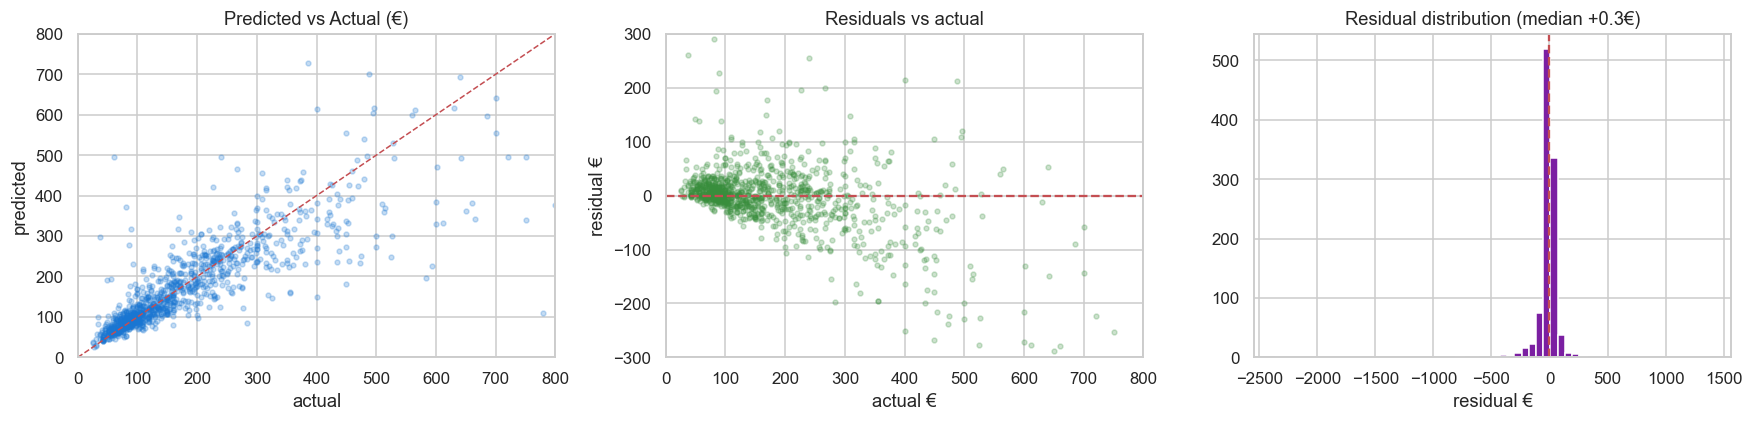

In [12]:
pred_log = xgb_fitted.predict(X_test)
pred_eur = np.expm1(pred_log)
true_eur = np.expm1(y_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(true_eur, pred_eur, alpha=0.25, s=10, color='#1976D2')
lim = [0, max(true_eur.max(), pred_eur.max())]
axes[0].plot(lim, lim, 'r--', lw=1)
axes[0].set(title='Predicted vs Actual (€)', xlabel='actual', ylabel='predicted',
            xlim=(0,800), ylim=(0,800))

resid = pred_eur - true_eur
axes[1].scatter(true_eur, resid, alpha=0.25, s=10, color='#388E3C')
axes[1].axhline(0, color='r', ls='--')
axes[1].set(title='Residuals vs actual', xlabel='actual €', ylabel='residual €',
            xlim=(0,800), ylim=(-300,300))

axes[2].hist(resid, bins=60, color='#7B1FA2', edgecolor='white')
axes[2].axvline(0, color='r', ls='--')
axes[2].set(title=f'Residual distribution (median {np.median(resid):+.1f}€)',
            xlabel='residual €')

plt.tight_layout()
plt.savefig('../reports/figures/06_residuals.png', dpi=140, bbox_inches='tight')
plt.show()

## 9. SHAP — global feature importance

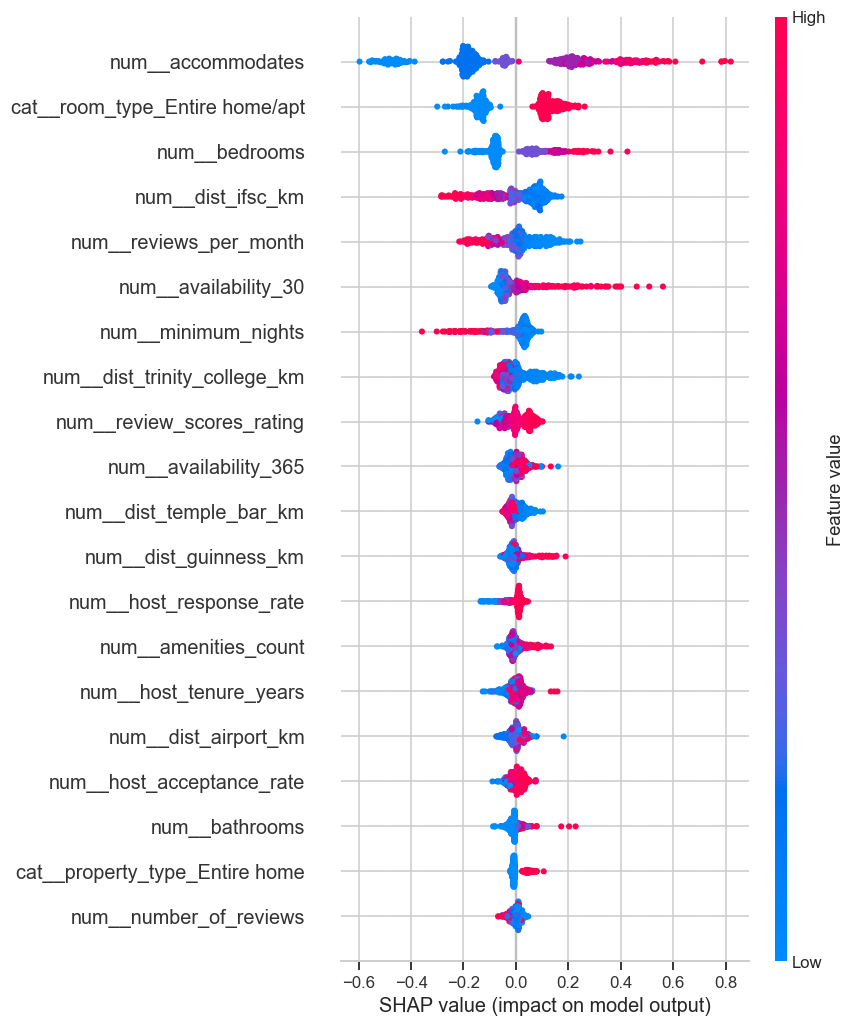

In [13]:
import shap

# Use the fitted XGBoost; pull out the inner sklearn estimator
xgb_model = xgb_fitted.named_steps['reg']
X_test_transformed = xgb_fitted.named_steps['pre'].transform(X_test)
feature_names = xgb_fitted.named_steps['pre'].get_feature_names_out()

# TreeExplainer is the fast path for tree models
explainer = shap.TreeExplainer(xgb_model)
sample_size = min(500, X_test_transformed.shape[0])
idx = np.random.RandomState(RANDOM_STATE).choice(
    X_test_transformed.shape[0], sample_size, replace=False
)
shap_vals = explainer.shap_values(X_test_transformed[idx])

shap.summary_plot(shap_vals, X_test_transformed[idx],
                  feature_names=feature_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig('../reports/figures/07_shap_summary.png', dpi=140, bbox_inches='tight')
plt.show()

## Key findings

| Model | RMSE (€) | MAE (€) | R² | Notes |
|---|---|---|---|---|
| Ridge | 178.47 | 64.70 | 0.655 | linear baseline |
| RandomForest | 158.12 | 57.67 | 0.725 | non-linear, slower |
| **XGBoost** | **140.72** | **52.03** | **0.775** | best; CV RMSE(log) 0.327 ± 0.031 |

Top SHAP drivers: `accommodates`, `bedrooms`, `room_type`,
`dist_city_center_km`, `bathrooms`, `is_commercial_host`.

> Honest about limits: model is trained on host-set prices (not realized
> booking prices). Actual transaction prices may differ via dynamic pricing.
